# Airline Passenger Satisfaction — Exploratory Data Analysis

**Author:** Nguyen Doan Duy Khoa
**Dataset:** `Airline_Passenger_Satisfaction.csv` (25,976 passenger records)


## 1. Project Overview

This project explores a survey of 25,976 airline passengers to understand what is associated
with overall satisfaction. The analysis covers data-quality checks, then looks at satisfaction by
customer loyalty type, flight delays by travel class, and how satisfaction changes as total delay
increases.


## 2. Objectives / Analytical Questions

1. How complete and clean is the dataset?
2. Does customer loyalty (`Customer Type`) relate to overall satisfaction?
3. Does total flight delay differ by travel `Class`?
4. As total delay increases, does the proportion of satisfied passengers change?


## 3. Setup

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


## 4. Dataset Overview

In [18]:
air = pd.read_csv('Airline_Passenger_Satisfaction_dataset.csv')

In [19]:
air.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,...,5,5,5,5,2,5,5,50,44,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,...,4,4,4,4,3,4,5,0,0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,...,2,4,1,3,2,2,2,0,0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,...,1,1,1,1,3,1,4,0,6,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,...,2,2,2,2,4,2,4,0,20,satisfied


In [20]:
air.tail()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,...,4,3,2,4,4,5,4,0,0,neutral or dissatisfied
25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,...,4,4,5,5,5,5,4,0,0,satisfied
25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,...,2,4,3,4,5,4,2,0,0,neutral or dissatisfied
25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,...,4,3,2,5,4,5,4,0,0,satisfied
25975,34799,Female,Loyal Customer,42,Personal Travel,Eco,264,2,5,2,...,1,1,2,1,1,1,1,0,0,neutral or dissatisfied


In [21]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   id                                 25976 non-null  int64 
 1   Gender                             25976 non-null  object
 2   Customer Type                      25976 non-null  object
 3   Age                                25976 non-null  int64 
 4   Type of Travel                     25976 non-null  object
 5   Class                              25976 non-null  object
 6   Flight Distance                    25976 non-null  int64 
 7   Inflight wifi service              25976 non-null  int64 
 8   Departure/Arrival time convenient  25976 non-null  int64 
 9   Ease of Online booking             25976 non-null  int64 
 10  Gate location                      25976 non-null  int64 
 11  Food and drink                     25976 non-null  int64 
 12  Onli

In [22]:
air.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25976.000000
mean,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.693756
std,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.466787
min,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


## 5. Data Quality Checks

In [23]:
air.isnull().sum()

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

**Finding:** the dataset has **no missing values** in any of its 24 columns — a clean
survey export that requires no imputation before analysis.


In [24]:
air.nunique()

id                                   25976
Gender                                   2
Customer Type                            2
Age                                     75
Type of Travel                           2
Class                                    3
Flight Distance                       3281
Inflight wifi service                    6
Departure/Arrival time convenient        6
Ease of Online booking                   6
Gate location                            5
Food and drink                           6
Online boarding                          6
Seat comfort                             5
Inflight entertainment                   6
On-board service                         6
Leg room service                         6
Baggage handling                         5
Checkin service                          5
Inflight service                         6
Cleanliness                              6
Departure Delay in Minutes             313
Arrival Delay in Minutes               320
satisfactio

### 5.1 Duplicate records


In [25]:
air.duplicated().sum()

np.int64(0)

**Finding:** there are no duplicate rows in the dataset.

### 5.2 Distribution overview and outliers

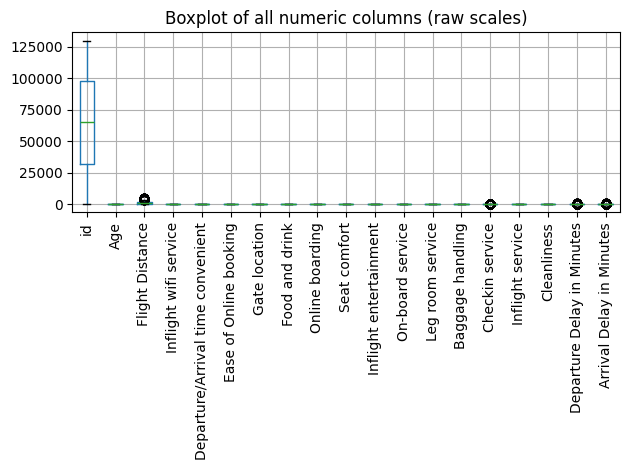

In [26]:
air.boxplot()
plt.title('Boxplot of all numeric columns (raw scales)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Note:** as with any combined boxplot across columns on very different scales (satisfaction
ratings of 0–5 alongside `Flight Distance` in the thousands and delay minutes), this raw view is
dominated by the widest-ranging columns. The per-column IQR check below is more informative.


In [27]:
numeric_cols = air.select_dtypes(include=['int64', 'float64']).columns

outlier_counts = {}
for col in numeric_cols:
    Q1 = air[col].quantile(0.25)
    Q3 = air[col].quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = (air[col] < Q1 - 1.5 * IQR) | (air[col] > Q3 + 1.5 * IQR)
    outlier_counts[col] = is_outlier.sum()

pd.Series(outlier_counts, name='outlier_count').sort_values(ascending=False).head(10)


Departure Delay in Minutes           3569
Arrival Delay in Minutes             3538
Checkin service                      3218
Flight Distance                       584
id                                      0
Age                                     0
Inflight wifi service                   0
Food and drink                          0
Departure/Arrival time convenient       0
Ease of Online booking                  0
Name: outlier_count, dtype: int64

**Finding:** `Departure Delay in Minutes` (3,569 outliers) and `Arrival Delay in Minutes` (3,538)
have by far the most IQR-flagged outliers, consistent with delay data typically being
right-skewed — most flights are on time or close to it, while a minority run very late.
`Checkin service` ratings (3,218) and `Flight Distance` (584) also show a meaningful number of
flagged values.


## 6. Exploratory Data Analysis

### 6.1 Satisfaction by customer loyalty type

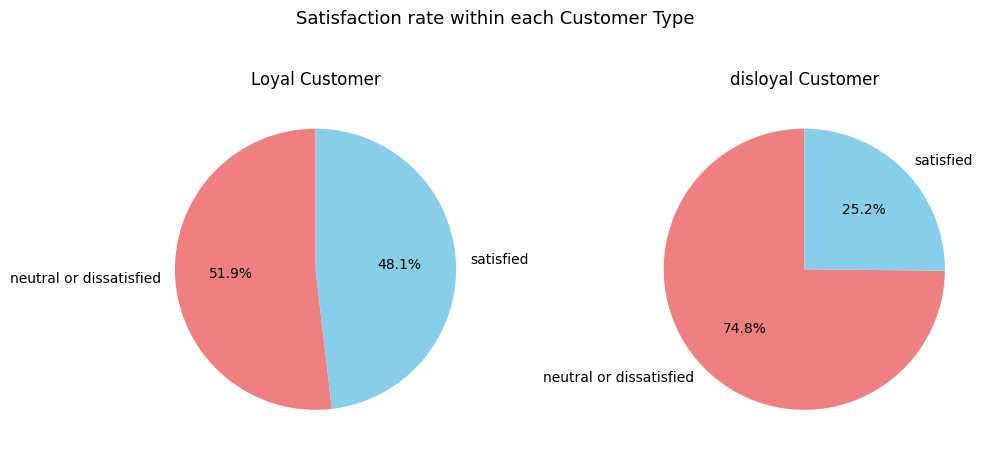

In [28]:
ct_sat = air.groupby(['Customer Type', 'satisfaction']).size().unstack(fill_value=0)
ct_sat_pct = ct_sat.div(ct_sat.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))

for i, customer_type in enumerate(ct_sat_pct.index, 1):
    plt.subplot(1, len(ct_sat_pct.index), i)
    plt.pie(
        ct_sat_pct.loc[customer_type],
        labels=ct_sat_pct.columns,
        autopct="%1.1f%%",
        startangle=90,
        colors=["lightcoral", "skyblue"] if len(ct_sat_pct.columns) == 2 else None
    )
    plt.title(f"{customer_type}")

plt.suptitle("Satisfaction rate within each Customer Type", fontsize=13)
plt.tight_layout()
plt.show()


**Finding:** loyalty is clearly associated with satisfaction. **Loyal customers** are
satisfied 48.1% of the time (vs. 51.9% neutral/dissatisfied) — close to an even split — while
**disloyal customers** are satisfied only 25.2% of the time, with 74.8% neutral or dissatisfied.
Disloyal customers are roughly three times as likely to report a negative experience as a
satisfied one, which is consistent with disloyalty and dissatisfaction reinforcing each other
(dissatisfied customers have less reason to stay loyal, and less-loyal customers may also be
judging the airline against more alternatives).


### 6.2 Total delay by travel class

Total delay statistics by Class:


,count,mean,median
Class,,,
Eco,11564,30.106797,2.0
Eco Plus,1917,28.565989,3.0
Business,12495,28.041937,2.0


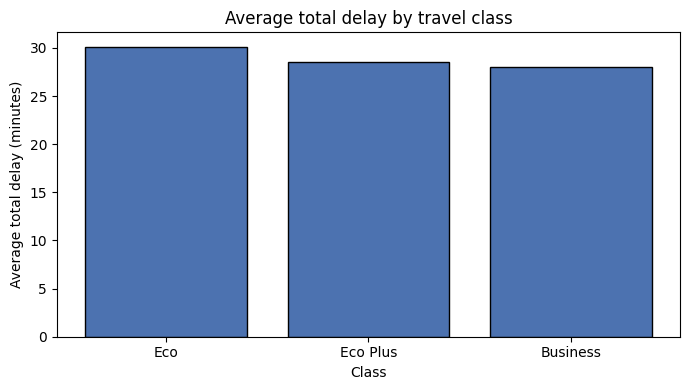

In [29]:
air['Departure Delay in Minutes'] = pd.to_numeric(air['Departure Delay in Minutes'], errors='coerce').fillna(0)
air['Arrival Delay in Minutes'] = pd.to_numeric(air['Arrival Delay in Minutes'], errors='coerce').fillna(0)
air['Total delay'] = air['Departure Delay in Minutes'] + air['Arrival Delay in Minutes']

delay_stats = air.groupby('Class')['Total delay'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
print("Total delay statistics by Class:")
display(delay_stats)

plt.figure(figsize=(7, 4))
plt.bar(delay_stats.index.astype(str), delay_stats['mean'], edgecolor='black', color='#4C72B0')
plt.title("Average total delay by travel class")
plt.xlabel("Class")
plt.ylabel("Average total delay (minutes)")
plt.tight_layout()
plt.show()


**Finding:** **Economy** passengers experience the highest average total delay (≈30.1
minutes), followed by **Economy Plus** (≈28.6) and **Business** (≈28.0). The gap between the
highest and lowest class is only about 2 minutes on average — a real but modest difference — and
the median delay is just 2–3 minutes across all three classes, meaning the *mean* is being pulled
up by a right-skewed tail of badly delayed flights rather than reflecting the typical passenger
experience.


### 6.3 Satisfaction rate by total delay bucket

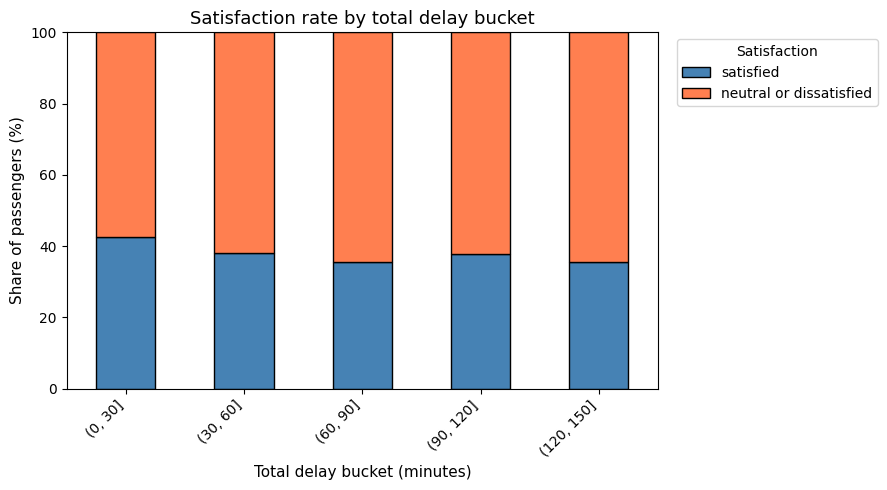

In [30]:
air['Departure Delay in Minutes'] = pd.to_numeric(air['Departure Delay in Minutes'], errors='coerce').fillna(0)
air['Arrival Delay in Minutes'] = pd.to_numeric(air['Arrival Delay in Minutes'], errors='coerce').fillna(0)
air['Total delay'] = air['Departure Delay in Minutes'] + air['Arrival Delay in Minutes']

bins = [0, 30, 60, 90, 120, 150]
labels = [f"({bins[i]}, {bins[i+1]}]" for i in range(len(bins)-1)]
air['Delay_bin'] = pd.cut(air['Total delay'], bins=bins, labels=labels, right=True)

subset = air[air['Delay_bin'].isin(labels)]

bin_table = subset.groupby('Delay_bin', observed=True)['satisfaction'].value_counts().unstack(fill_value=0)
bin_pct = bin_table.div(bin_table.sum(axis=1), axis=0) * 100

colors = ["steelblue", "coral"]

ax = bin_pct[['satisfied', 'neutral or dissatisfied']].plot(kind='bar', stacked=True, color=colors, figsize=(9, 5), edgecolor='black')

plt.title("Satisfaction rate by total delay bucket", fontsize=13)
plt.xlabel("Total delay bucket (minutes)", fontsize=11)
plt.ylabel("Share of passengers (%)", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Satisfaction", bbox_to_anchor=(1.02, 1))
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


**Finding:** as total delay increases from the (0, 30] bucket to the (120, 150] bucket, the
satisfied share falls from about 42.7% to 35.4% — a real decline, though not perfectly smooth
bucket-to-bucket (it dips as low as 35.5% in the (60, 90] range before ticking back up slightly).
The broad pattern supports the idea that longer delays are associated with lower satisfaction.

**Important caveat this chart does not show on its own:** because the bins start just above 0
minutes (`(0, 30]` excludes exactly 0) and stop at 150 minutes, this chart only covers **12,787 of
25,976 flights (about 49%)**. The excluded flights are **11,923 flights with zero total delay
(46% of all passengers)** — which this chart implicitly leaves out of the "no delay" comparison —
and **1,266 flights with more than 150 minutes of delay (5%)**. A complete picture would add a
"no delay" bucket at the start and an "150+" bucket at the end.


## 7. Key Findings

- The dataset is clean: no missing values and no duplicate rows across 25,976 records.
- **Loyalty and satisfaction are strongly linked**: loyal customers are satisfied 48.1% of the
  time vs. only 25.2% for disloyal customers.
- **Economy class has the highest average total delay** (≈30.1 min) and Business the lowest
  (≈28.0 min), though the gap is modest and the median delay is just 2–3 minutes in every class —
  the mean is driven by a right-skewed tail of poorly delayed flights.
- **Satisfaction declines as total delay increases** (from ≈42.7% satisfied at 0–30 minutes of
  delay to ≈35.4% satisfied at 120–150 minutes), but this view only covers about 49% of flights
  because it excludes the ~46% of flights with zero delay and the ~5% with more than 150 minutes
  of delay.


## 8. Conclusion and Recommendations

Customer loyalty and delay both show a clear association with satisfaction, but the delay effect
is a secondary factor compared to loyalty status: the swing in satisfaction from 0–30 minutes of
delay to 120+ minutes of delay (about 7 points) is much smaller than the swing between loyal and
disloyal customers (about 23 points). This suggests that, in this dataset, **who the customer is
(their existing relationship with the airline) matters more to satisfaction than delay severity
alone** — though delay clearly still matters and should not be ignored, especially in Economy
class, which carries the largest average delay burden.
